# Pneumatic chicken-wing tip-deflection benchmark

Quantifies how far the pneumatic actuator deflects the wing tip, across tissue
fixation methods. Deflection is normalized by the graph-paper grid and reported
in **mm** (1 mm per small square).

**Run order**
1. `python track_tips.py` — for each clip: calibrate the grid (default **ruler**:
   click two intersections N squares apart), then draw a **small, tight** box on
   the wing tip. Writes tracks to `deflection_analysis/tracks/` and verification
   videos to `deflection_analysis/overlays/`.
2. **Review the overlays** — confirm the red dot rides the tip.
3. For any clip that drifts or missed the tip, redo it:
   - `python track_tips.py --video "<path>" --redo` (redraw a tighter box), or
   - `python track_tips.py --video "<path>" --redo --manual` (hand-annotate the
     tip every ~15 frames — bulletproof for hard clips).
4. Run this notebook to aggregate and plot.

Two metrics per video:
- **Max deflection from rest** — largest tip displacement from its resting
  (unactuated) position. *"How far can the motor push the tip."*
- **Peak-to-peak travel** — full range of tip motion along its dominant axis.

In [10]:
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import deflection_config as cfg
import wing_deflection as wd

os.makedirs(cfg.PLOTS_DIR, exist_ok=True)

# --- load every per-video result; recompute mm from the PIXEL track ---------
# Metrics are derived live from x_px/y_px and the calibrated scale, so fixing a
# clip's scale in cfg.GRID_OVERRIDE corrects it WITHOUT re-tracking.
rows, tracks = [], {}
for jp in sorted(glob.glob(os.path.join(cfg.TRACKS_DIR, '*.json'))):
    with open(jp) as f:
        meta = json.load(f)
    rel = meta['rel_path']
    t = pd.read_csv(jp[:-5] + '.csv') if os.path.exists(jp[:-5] + '.csv') else None

    # scale: prefer the config override, else what was stored at track time
    pps = cfg.GRID_OVERRIDE.get(rel)
    px_per_mm = (pps / cfg.GRID_MM_PER_SQUARE) if pps else meta.get('px_per_mm')

    if t is not None and px_per_mm:
        m = wd.compute_metrics(t['x_px'].values, t['y_px'].values, px_per_mm,
                               rest_frames=cfg.REST_FRAMES)
        t = t.copy()
        t['disp_mm'] = m['disp_mm']               # refresh mm columns to live scale
        meta['max_deflection_mm'] = m['max_deflection_mm']
        meta['peak_to_peak_mm'] = m['peak_to_peak_mm']
        meta['px_per_mm'] = px_per_mm
        meta['px_per_square'] = px_per_mm * cfg.GRID_MM_PER_SQUARE
    tracks[rel] = t
    rows.append(meta)

if not rows:
    raise SystemExit('No results yet. Run:  python track_tips.py')

df = pd.DataFrame(rows)
df['video'] = df['rel_path'].apply(lambda p: os.path.basename(p))
df['mode'] = df.get('mode', df.get('tracker'))
keep = ['group','video','max_deflection_mm','peak_to_peak_mm','px_per_mm',
        'px_per_square','grid_confidence','median_score','nframes','mode']
keep = [k for k in keep if k in df.columns]
summary = df[keep].sort_values(['group','video']).reset_index(drop=True)
summary.to_csv(os.path.join(cfg.RESULTS_DIR, 'per_video_summary.csv'), index=False)
print(f'{len(summary)} videos loaded across {summary.group.nunique()} groups')
summary

21 videos loaded across 7 groups


,group,video,max_deflection_mm,peak_to_peak_mm,px_per_mm,px_per_square,grid_confidence,median_score,nframes,mode
0,2.5%_formalin_1day,2.5%_formalin_1day_1.MOV,1.944052,2.249470,47.0,47.0,100.000000,0.997718,2212,ncc
1,2.5%_formalin_1day,2.5%_formalin_1day_2.MOV,1.177547,1.275272,47.0,47.0,5.536899,0.993979,908,NaN
2,2.5%_formalin_1day,2.5%_formalin_1day_3.MOV,0.834397,0.946724,47.0,47.0,4.306172,0.993479,605,NaN
3,5%_formalin_2day,5%_formalin_tricep_1.MOV,1.947121,2.096165,46.0,46.0,9.797704,0.984371,882,NaN
4,5%_formalin_2day,5%_formalin_tricep_2.MOV,1.787964,1.871827,46.0,46.0,100.000000,0.997984,743,ncc
5,5%_formalin_2day,5%_formalin_tricep_3.MOV,1.399880,1.401104,46.0,46.0,7.792232,0.991126,672,NaN
6,5%_formalin_2day,5%_formalin_tricep_4.MOV,1.361065,1.387696,46.0,46.0,4.936062,0.980783,792,NaN
7,70%_EtOH_1day,70%_EtOH_1days_1.MOV,2.361208,3.683268,49.0,49.0,11.037604,0.993250,712,NaN
8,70%_EtOH_1day,70%_EtOH_1days_3.1.MOV,0.790391,0.626389,49.0,49.0,2.952691,0.984540,744,NaN
9,70%_EtOH_1day,70%_EtOH_1days_3.MOV,0.573086,0.559641,49.0,49.0,4.791676,0.990277,507,NaN


In [11]:
# --- quality check: flag videos worth re-reviewing -------------------------
qc = summary.copy()
qc['low_grid_conf'] = qc['grid_confidence'] < 30
# match-score check applies to automatic trackers, not manual keyframes.
# NOTE: a tracker can drift while still reporting a high score, so ALWAYS
# eyeball the overlays too -- this only catches total loss / low confidence.
is_auto = qc['mode'].isin(['csrt', 'ncc', 'mil']) if 'mode' in qc else True
qc['low_track_score'] = is_auto & (qc['median_score'] < 0.5)
flagged = qc[qc['low_grid_conf'] | qc['low_track_score']]
if len(flagged):
    print('Review these — re-run e.g.:')
    print('  python track_tips.py --video "<path>" --redo            (redraw a SMALL TIGHT tip box; CSRT default)')
    print('  python track_tips.py --video "<path>" --redo --manual   (hand-annotate, last resort)')
    cols = [c for c in ['group','video','mode','grid_confidence','median_score',
                        'px_per_square','low_grid_conf','low_track_score'] if c in flagged]
    display(flagged[cols])
else:
    print('All loaded videos passed grid-confidence and tracking-score checks.')
print('\\nAlways spot-check deflection_analysis/overlays/*.mp4 — a tracker can drift at score 1.0.')

Review these — re-run e.g.:
  python track_tips.py --video "<path>" --redo            (redraw a SMALL TIGHT tip box; CSRT default)
  python track_tips.py --video "<path>" --redo --manual   (hand-annotate, last resort)


,group,video,mode,grid_confidence,median_score,px_per_square,low_grid_conf,low_track_score
1,2.5%_formalin_1day,2.5%_formalin_1day_2.MOV,NaN,5.536899,0.993979,47.0,True,False
2,2.5%_formalin_1day,2.5%_formalin_1day_3.MOV,NaN,4.306172,0.993479,47.0,True,False
3,5%_formalin_2day,5%_formalin_tricep_1.MOV,NaN,9.797704,0.984371,46.0,True,False
5,5%_formalin_2day,5%_formalin_tricep_3.MOV,NaN,7.792232,0.991126,46.0,True,False
6,5%_formalin_2day,5%_formalin_tricep_4.MOV,NaN,4.936062,0.980783,46.0,True,False
7,70%_EtOH_1day,70%_EtOH_1days_1.MOV,NaN,11.037604,0.993250,49.0,True,False
8,70%_EtOH_1day,70%_EtOH_1days_3.1.MOV,NaN,2.952691,0.984540,49.0,True,False
9,70%_EtOH_1day,70%_EtOH_1days_3.MOV,NaN,4.791676,0.990277,49.0,True,False
12,70%_EtOH_1day_core_removed,70%_EtOH_1days_2_forearm_core_taken_out.MOV,NaN,3.513003,0.923611,49.0,True,False
13,70%_EtOH_1day_core_removed,70%_EtOH_1days_2_forearm_core_taken_out_2.MOV,NaN,3.189377,0.944094,49.0,True,False


\nAlways spot-check deflection_analysis/overlays/*.mp4 — a tracker can drift at score 1.0.


In [12]:
# --- load wing sizes & normalize deflection --------------------------------
# We normalize by the PROXIMAL (shoulder->elbow / humerus) length: a pose-
# invariant scale that doesn't change with how the wing is folded at the
# elbow/wrist, unlike the full caliper length. Measure it with:
#     python wing_size.py --proximal
# Until then this falls back to caliper_length_mm so the notebook still runs.
# (deflection and any length both scale as px/(px per mm), so the RATIO is
# independent of the grid calibration.)
NORM_BY = 'proximal_length_mm'   # also valid: 'caliper_length_mm', 'sqrt_area_mm'
SIZE_LABEL = {'proximal_length_mm': 'proximal (humerus) length',
              'caliper_length_mm': 'wing length',
              'sqrt_area_mm': 'wing size'}

wrows = []
for jp in sorted(glob.glob(os.path.join(cfg.WING_SIZE_DIR, '*.json'))):
    with open(jp) as f:
        wrows.append(json.load(f))

if wrows:
    wing = pd.DataFrame(wrows)
    wing['video'] = wing['rel_path'].apply(os.path.basename)
    wing = wing.rename(columns={'mode': 'size_mode', 'seg_ok': 'size_ok'})
    for col in ('proximal_length_mm',):          # may be absent until measured
        if col not in wing:
            wing[col] = np.nan
    summary = summary.merge(
        wing[['video', 'sqrt_area_mm', 'caliper_length_mm', 'proximal_length_mm',
              'area_mm2', 'size_mode', 'size_ok']],
        on='video', how='left')

    # fall back if the chosen normalizer hasn't been measured for every clip
    if summary[NORM_BY].notna().sum() < len(summary):
        have = int(summary[NORM_BY].notna().sum())
        print(f"** {NORM_BY} measured for only {have}/{len(summary)} clips. "
              f"Run:  python wing_size.py --proximal")
        if have == 0:
            NORM_BY = 'caliper_length_mm'
            print(f"   -> falling back to {NORM_BY} for now.")

    summary['norm_defl'] = summary['max_deflection_mm'] / summary[NORM_BY]
    summary['norm_p2p']  = summary['peak_to_peak_mm']  / summary[NORM_BY]
    summary.to_csv(os.path.join(cfg.RESULTS_DIR, 'per_video_summary.csv'), index=False)

    print(f"Normalizing deflection by {NORM_BY} ({SIZE_LABEL.get(NORM_BY, NORM_BY)}).")
    print('Spot-check deflection_analysis/wing_size/*.png and _all_outlines.png.')
    display(summary[['group', 'video', 'max_deflection_mm', NORM_BY,
                     'norm_defl', 'size_mode']])
else:
    print('No wing sizes found. Run:  python wing_size.py   (then --proximal)')
    for c in ('sqrt_area_mm', 'caliper_length_mm', 'proximal_length_mm',
              'norm_defl', 'norm_p2p'):
        summary[c] = np.nan

Normalizing deflection by proximal_length_mm (proximal (humerus) length).
Spot-check deflection_analysis/wing_size/*.png and _all_outlines.png.


,group,video,max_deflection_mm,proximal_length_mm,norm_defl,size_mode
0,2.5%_formalin_1day,2.5%_formalin_1day_1.MOV,1.944052,11.358195,0.171159,manual
1,2.5%_formalin_1day,2.5%_formalin_1day_2.MOV,1.177547,11.208405,0.105059,manual
2,2.5%_formalin_1day,2.5%_formalin_1day_3.MOV,0.834397,11.239300,0.074239,manual
3,5%_formalin_2day,5%_formalin_tricep_1.MOV,1.947121,11.702943,0.166379,auto
4,5%_formalin_2day,5%_formalin_tricep_2.MOV,1.787964,12.986269,0.137681,auto
5,5%_formalin_2day,5%_formalin_tricep_3.MOV,1.399880,12.245288,0.114320,auto
6,5%_formalin_2day,5%_formalin_tricep_4.MOV,1.361065,12.408931,0.109684,auto
7,70%_EtOH_1day,70%_EtOH_1days_1.MOV,2.361208,12.335667,0.191413,auto
8,70%_EtOH_1day,70%_EtOH_1days_3.1.MOV,0.790391,12.318453,0.064163,auto
9,70%_EtOH_1day,70%_EtOH_1days_3.MOV,0.573086,12.504360,0.045831,auto


In [13]:
# --- aggregate per group (mean +/- SEM, n) ---------------------------------
def agg(metric):
    g = summary.groupby('group')[metric]
    out = pd.DataFrame({'mean': g.mean(), 'sem': g.sem(ddof=1), 'n': g.count()})
    return out.reindex([gp for gp in cfg.GROUP_ORDER if gp in out.index])

agg_max = agg('max_deflection_mm')
agg_p2p = agg('peak_to_peak_mm')
group_stats = agg_max.join(agg_p2p, lsuffix='_maxdefl', rsuffix='_p2p')
group_stats.to_csv(os.path.join(cfg.RESULTS_DIR, 'group_stats.csv'))
group_stats

,mean_maxdefl,sem_maxdefl,n_maxdefl,mean_p2p,sem_p2p,n_p2p
group,,,,,,
fresh,6.466304,0.329530,4,6.927763,0.459660,4
fresh_double_actuator,4.765755,0.267166,2,6.091537,1.015247,2
5%_formalin_2day,1.624008,0.144527,4,1.689198,0.176276,4
2.5%_formalin_1day,1.318665,0.328009,3,1.490489,0.391163,3
70%_EtOH_1day,1.241562,0.563327,3,1.623099,1.030264,3
70%_EtOH_1day_core_removed,4.644978,0.322764,4,4.839240,0.445952,4
70%_EtOH_4day,1.882695,NaN,1,1.987658,NaN,1


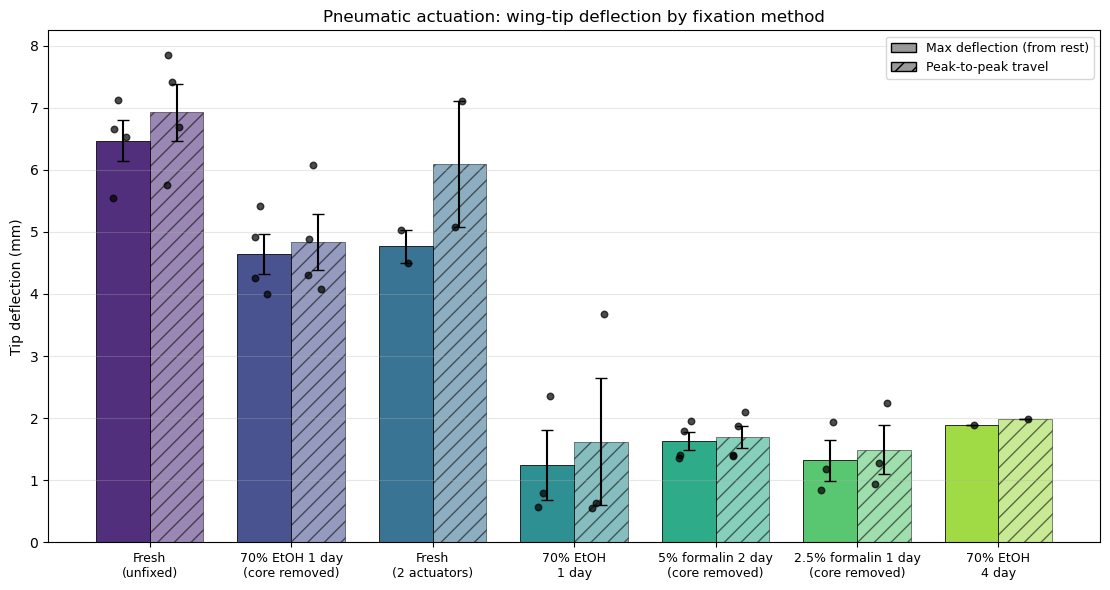

In [14]:
# --- benchmark bar chart: both metrics, with individual points + SEM -------
# Order columns from MOST to LEAST deflection (by the group's MAX max-deflection).
_present = [g for g in cfg.GROUP_ORDER if g in summary['group'].values]
groups = sorted(_present,
                key=lambda g: summary.loc[summary.group==g, 'max_deflection_mm'].max(),
                reverse=True)
labels = [cfg.GROUP_LABELS.get(g, g) for g in groups]
x = np.arange(len(groups)); width = 0.38
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(groups)))

fig, ax = plt.subplots(figsize=(max(9, 1.6*len(groups)), 6))
specs = [('max_deflection_mm', -width/2, 'Max deflection', 0.95),
         ('peak_to_peak_mm',    width/2, 'Peak-to-peak', 0.55)]
for metric, off, lab, alpha in specs:
    means = [summary.loc[summary.group==g, metric].mean() for g in groups]
    sems  = [summary.loc[summary.group==g, metric].sem(ddof=1) for g in groups]
    sems  = [0 if (s!=s) else s for s in sems]
    bars = ax.bar(x+off, means, width, yerr=sems, capsize=4, alpha=alpha,
                  color=colors, edgecolor='k', linewidth=0.6, label=lab,
                  hatch='' if metric=='max_deflection_mm' else '//')
    # individual video points
    for xi, g in zip(x+off, groups):
        pts = summary.loc[summary.group==g, metric].values
        jit = (np.random.default_rng(0).uniform(-0.07,0.07,len(pts)))
        ax.scatter(np.full(len(pts), xi)+jit, pts, s=22, color='k',
                   zorder=3, alpha=0.7)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('Tip deflection (mm)')
ax.set_title('Pneumatic actuation: wing-tip deflection by fixation method')
# legend that explains solid vs hatched
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='0.6', edgecolor='k', label='Max deflection (from rest)'),
                   Patch(facecolor='0.6', edgecolor='k', hatch='//', label='Peak-to-peak travel')],
          loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.PLOTS_DIR, 'benchmark_bar.png'), dpi=150)
plt.show()

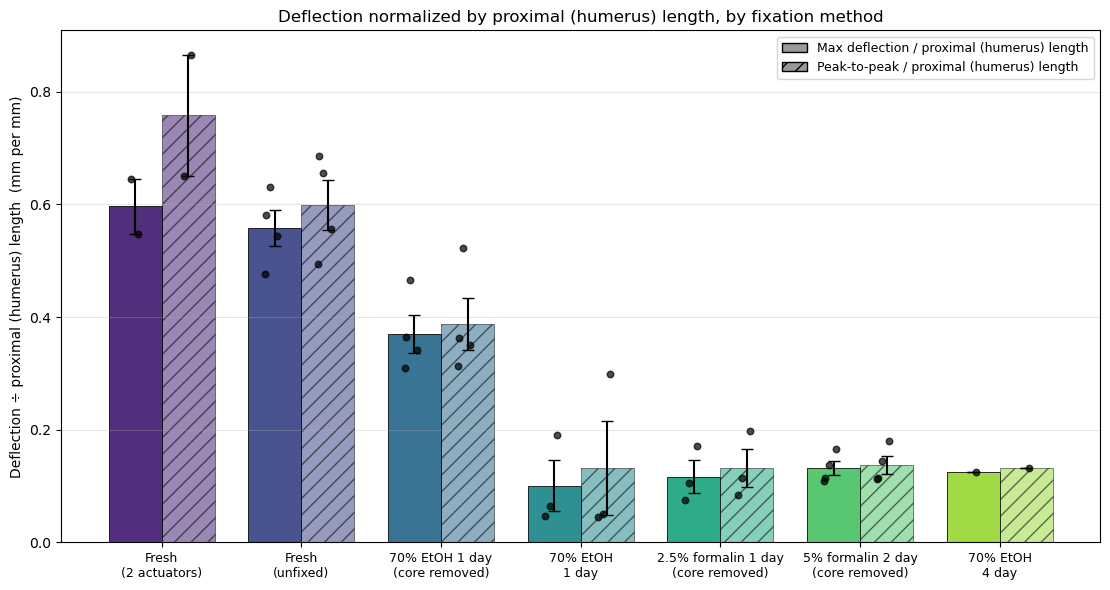

In [15]:
# --- SIZE-NORMALIZED bar chart: deflection / wing size ---------------------
# Same layout as the raw chart, but every value is divided by NORM_BY (set
# above -- proximal/humerus length by default), so it's "deflection per unit of
# that size" -- a fair, pose-invariant comparison across wings.
# Dimensionless (mm / mm). Bars ordered most -> least by the group's MAX.
size_name = SIZE_LABEL.get(NORM_BY, NORM_BY)
nsum = summary.dropna(subset=['norm_defl'])
ngroups = sorted([g for g in cfg.GROUP_ORDER if g in nsum['group'].values],
                 key=lambda g: nsum.loc[nsum.group==g, 'norm_defl'].max(),
                 reverse=True)
nlabels = [cfg.GROUP_LABELS.get(g, g) for g in ngroups]
x = np.arange(len(ngroups)); width = 0.38
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(ngroups)))

fig, ax = plt.subplots(figsize=(max(9, 1.6*len(ngroups)), 6))
specs = [('norm_defl', -width/2, 'Max deflection', 0.95),
         ('norm_p2p',   width/2, 'Peak-to-peak', 0.55)]
for metric, off, lab, alpha in specs:
    means = [nsum.loc[nsum.group==g, metric].mean() for g in ngroups]
    sems  = [nsum.loc[nsum.group==g, metric].sem(ddof=1) for g in ngroups]
    sems  = [0 if (s!=s) else s for s in sems]
    ax.bar(x+off, means, width, yerr=sems, capsize=4, alpha=alpha,
           color=colors, edgecolor='k', linewidth=0.6,
           hatch='' if metric=='norm_defl' else '//')
    for xi, g in zip(x+off, ngroups):
        pts = nsum.loc[nsum.group==g, metric].values
        jit = np.random.default_rng(0).uniform(-0.07, 0.07, len(pts))
        ax.scatter(np.full(len(pts), xi)+jit, pts, s=22, color='k',
                   zorder=3, alpha=0.7)

ax.set_xticks(x); ax.set_xticklabels(nlabels, fontsize=9)
ax.set_ylabel(f'Deflection ÷ {size_name}  (mm per mm)')
ax.set_title(f'Deflection normalized by {size_name}, by fixation method')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='0.6', edgecolor='k', label=f'Max deflection / {size_name}'),
                   Patch(facecolor='0.6', edgecolor='k', hatch='//', label=f'Peak-to-peak / {size_name}')],
          loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.PLOTS_DIR, 'benchmark_bar_normalized.png'), dpi=150)
plt.show()

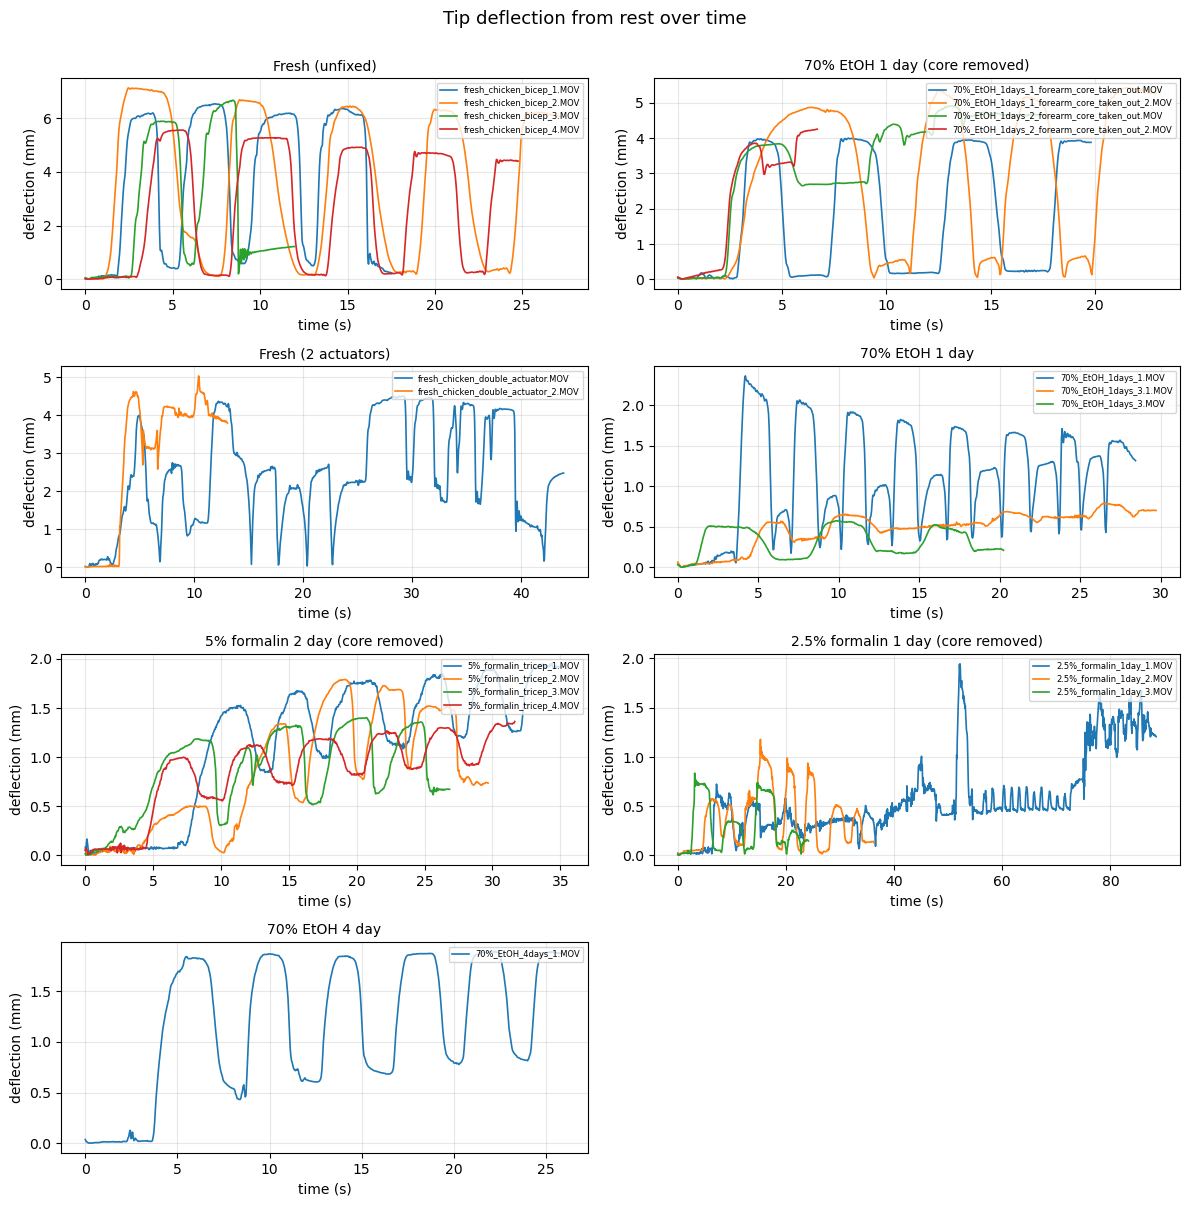

In [16]:
# --- deflection time-series, one panel per group ---------------------------
ncol = 2; nrow = int(np.ceil(len(groups)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(12, 3.0*nrow), squeeze=False)
for i, g in enumerate(groups):
    ax = axes[i//ncol][i%ncol]
    vids = summary.loc[summary.group==g, 'video']
    for rel, t in tracks.items():
        if t is None or os.path.basename(rel) not in set(vids):
            continue
        ax.plot(t['t_s'], t['disp_mm'], lw=1.2, label=os.path.basename(rel))
    ax.set_title(cfg.GROUP_LABELS.get(g, g).replace(chr(10),' '), fontsize=10)
    ax.set_xlabel('time (s)'); ax.set_ylabel('deflection (mm)')
    ax.grid(alpha=0.3); ax.legend(fontsize=6, loc='upper right')
for j in range(len(groups), nrow*ncol):
    axes[j//ncol][j%ncol].axis('off')
fig.suptitle('Tip deflection from rest over time', y=1.001, fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(cfg.PLOTS_DIR, 'deflection_timeseries.png'), dpi=150)
plt.show()

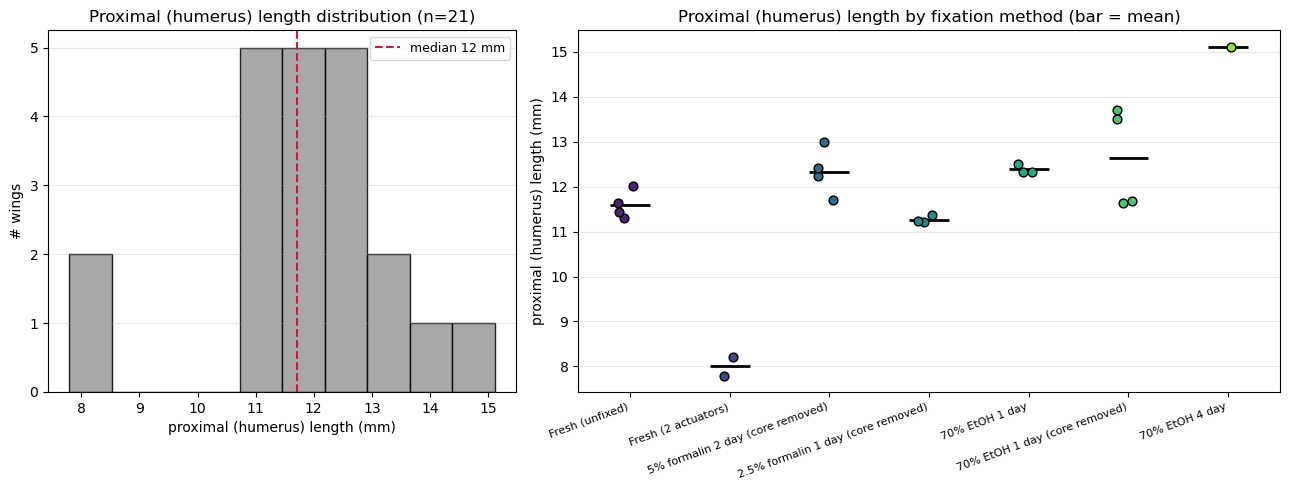

In [17]:
# --- wing-size distribution -------------------------------------------------
# Spread of the size used for normalization (NORM_BY -- proximal/humerus length
# by default). Left: overall distribution. Right: per group, so you can see
# whether a normalized difference is just driven by a size difference.
size_name = SIZE_LABEL.get(NORM_BY, NORM_BY)
wsum = summary.dropna(subset=[NORM_BY])
fig, (axh, axg) = plt.subplots(1, 2, figsize=(13, 5),
                               gridspec_kw={'width_ratios': [1, 1.5]})

axh.hist(wsum[NORM_BY], bins=10, color='0.6', edgecolor='k', alpha=0.85)
axh.axvline(wsum[NORM_BY].median(), color='crimson', ls='--',
            label=f"median {wsum[NORM_BY].median():.0f} mm")
axh.set_xlabel(f'{size_name} (mm)'); axh.set_ylabel('# wings')
axh.set_title(f"{size_name.capitalize()} distribution (n={len(wsum)})")
axh.legend(fontsize=9); axh.grid(axis='y', alpha=0.3)

gorder = [g for g in cfg.GROUP_ORDER if g in wsum['group'].values]
colors = plt.cm.viridis(np.linspace(0.1, 0.85, len(gorder)))
for i, (g, c) in enumerate(zip(gorder, colors)):
    L = wsum.loc[wsum.group==g, NORM_BY].values
    jit = np.random.default_rng(0).uniform(-0.12, 0.12, len(L))
    axg.scatter(np.full(len(L), i)+jit, L, s=40, color=c, edgecolor='k', zorder=3)
    if len(L):
        axg.hlines(L.mean(), i-0.2, i+0.2, color='k', lw=2, zorder=2)
axg.set_xticks(range(len(gorder)))
axg.set_xticklabels([cfg.GROUP_LABELS.get(g, g).replace(chr(10), ' ') for g in gorder],
                    fontsize=8, rotation=20, ha='right')
axg.set_ylabel(f'{size_name} (mm)')
axg.set_title(f'{size_name.capitalize()} by fixation method (bar = mean)')
axg.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(cfg.PLOTS_DIR, 'wing_size_distribution.png'), dpi=150)
plt.show()

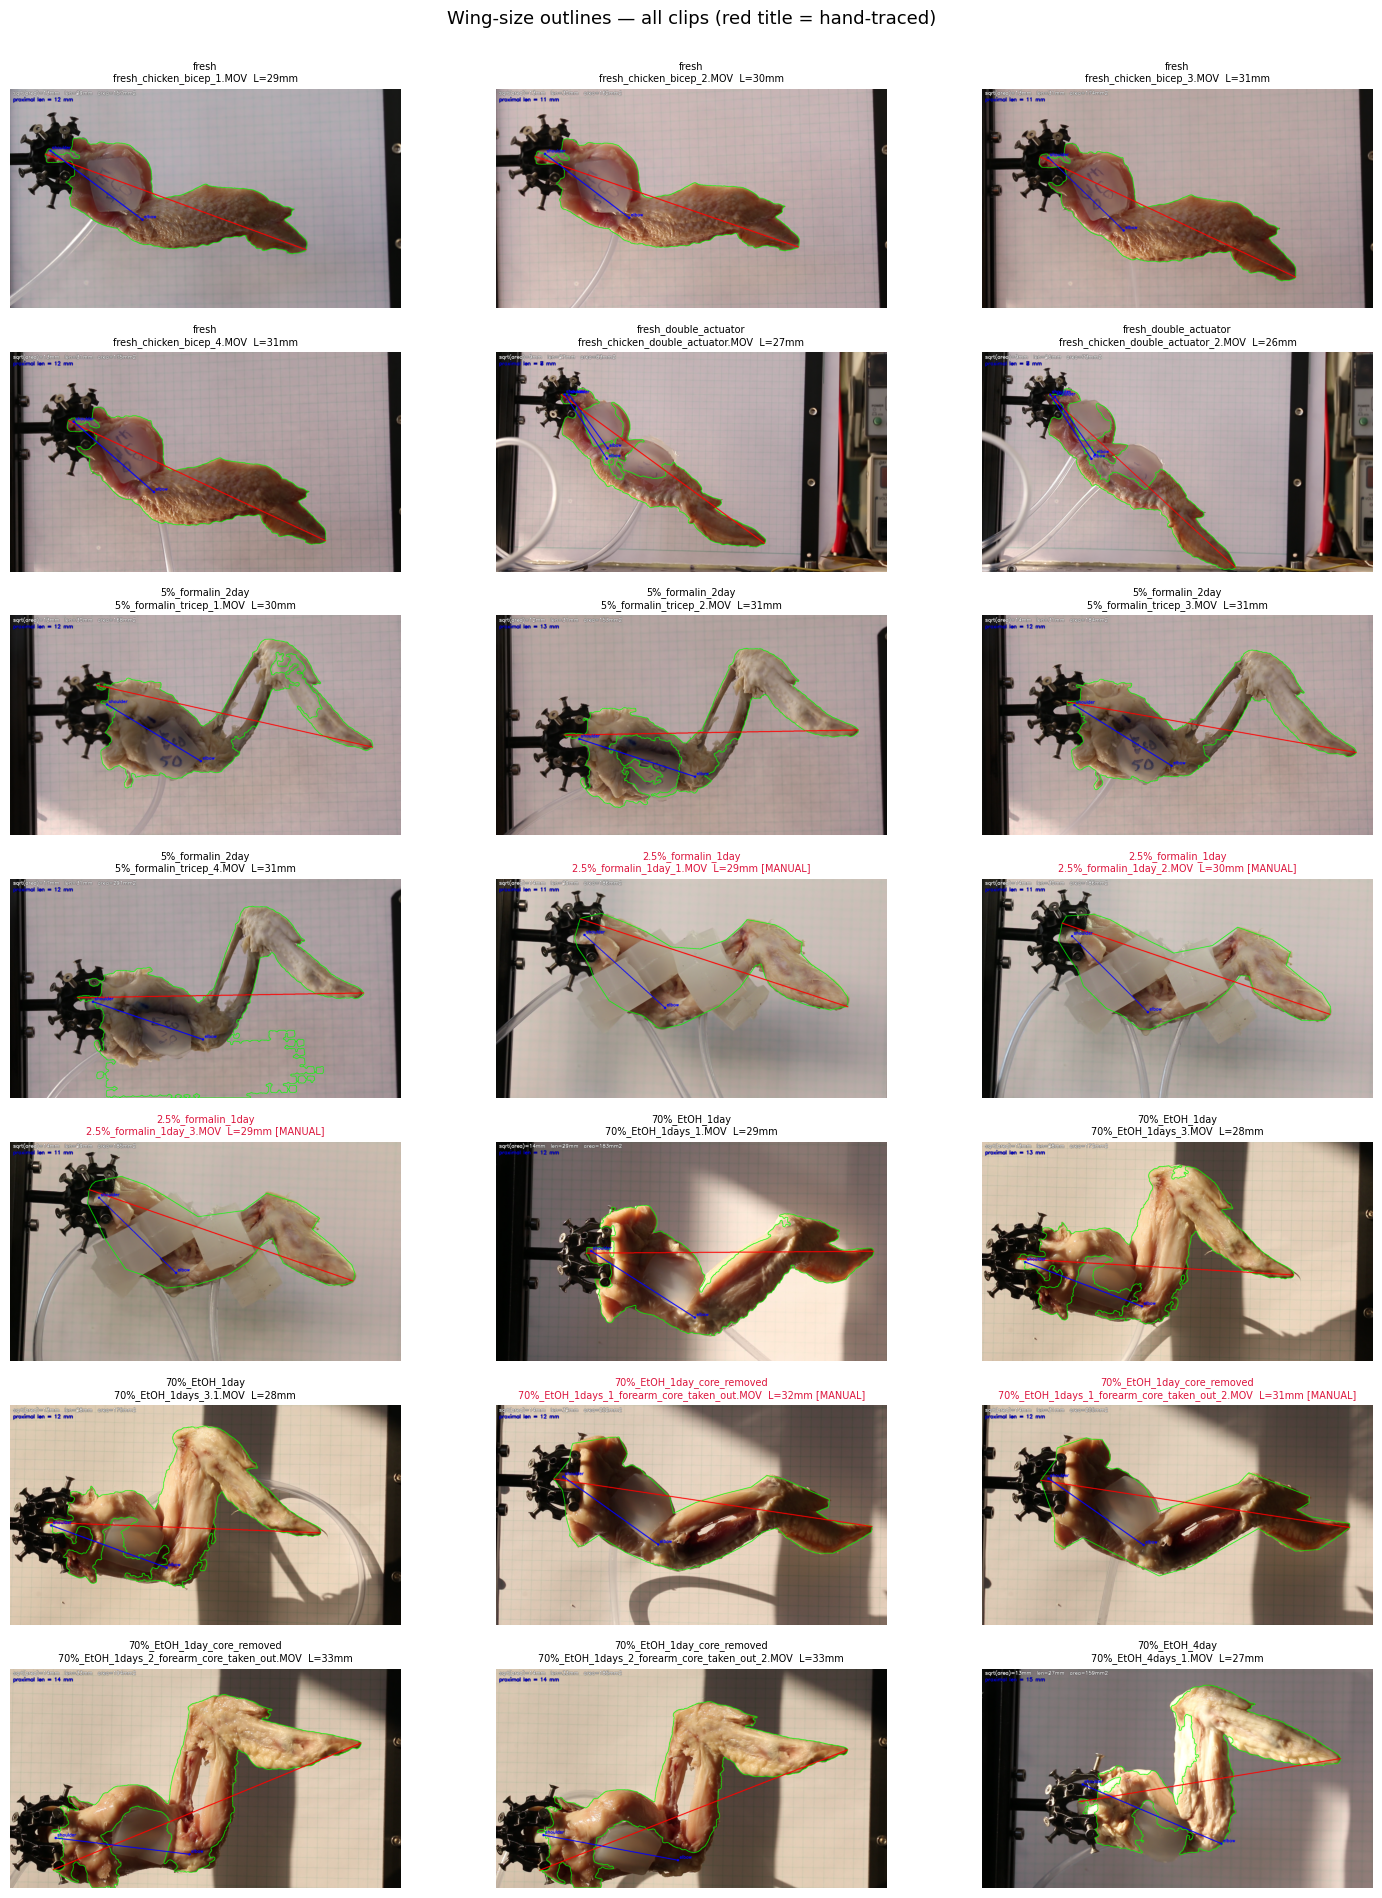

In [18]:
# --- contact sheet: every wing-size outline in one place (QC) --------------
# Tiles all wing_size/*.png so you can eyeball the segmentation at a glance.
# Hand-traced clips get a red title. Saved to wing_size/_all_outlines.png.
items = list(cfg.all_videos())
ncol = 3; nrow = int(np.ceil(len(items)/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(15, 2.7*nrow))
axes = axes.ravel()
for ax in axes:
    ax.axis('off')
for i, (g, ab, rel) in enumerate(items):
    stem = cfg.result_stem(rel)
    png = os.path.join(cfg.WING_SIZE_DIR, stem + '.png')
    jp  = os.path.join(cfg.WING_SIZE_DIR, stem + '.json')
    if os.path.exists(png):
        axes[i].imshow(plt.imread(png))
    m = json.load(open(jp)) if os.path.exists(jp) else {}
    mode = m.get('mode', '?'); L = m.get('caliper_length_mm', 0)
    tag = ' [MANUAL]' if mode == 'manual' else ''
    axes[i].set_title(f"{g}\n{os.path.basename(rel)}  L={L:.0f}mm{tag}",
                      fontsize=7, color=('crimson' if mode == 'manual' else 'black'))
fig.suptitle('Wing-size outlines — all clips (red title = hand-traced)',
             fontsize=13, y=1.002)
plt.tight_layout()
plt.savefig(os.path.join(cfg.WING_SIZE_DIR, '_all_outlines.png'),
            dpi=110, bbox_inches='tight')
plt.show()